# Projeto de Ciência de Dados - Bitcoin Prices
**Autor:** Kauan da Costa Barros  
**Dataset:** Preços Históricos e Projeções de Bitcoin (2010 - 2026)

---
## 1ª Etapa 
## 1. Introdução e Objetivo
Este notebook apresenta o processo de limpeza e tratamento de dados de uma série temporal de preços do Bitcoin. O objetivo é preparar os dados para tarefas subsequentes de **Regressão** (predição de preço) e **Classificação** (categoria de preço).

### 2. Importação de Bibliotecas e Carga dos Dados
Nesta etapa, carregamos o `pandas` para manipulação de DataFrames e o `numpy` para operações matemáticas vetorizadas.

In [1]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv('bitcoin.csv')
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    print("Arquivo não encontrado. Verifique o caminho.")

Dataset carregado com sucesso!


### 3. Algoritmo de Limpeza e Ordenação Cronológica
O processo de limpeza segue as seguintes regras de negócio:
1. **Padronização Temporal**: Conversão para o formato `datetime`.
2. **Ordenação**: Organização cronológica (do mais antigo ao mais recente).
3. **Unicidade**: Remoção de possíveis duplicatas por data.
4. **Integridade Lógica**: Garantir que a máxima (`High`) não seja inferior aos outros preços do dia usando **NumPy**.
5. **Continuidade**: Preenchimento de lacunas via interpolação linear.

In [2]:

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by='Date').reset_index(drop=True)

df = df.drop_duplicates(subset=['Date'], keep='first')

df['High'] = np.maximum(df['High'], df[['Open', 'Low', 'Close']].max(axis=1))
df['Low'] = np.minimum(df['Low'], df[['Open', 'High', 'Close']].min(axis=1))


cols_num = ['Open', 'High', 'Low', 'Close', 'Volume']
df[cols_num] = df[cols_num].interpolate(method='linear')

print("Processamento de limpeza e ordenação concluído.")

Processamento de limpeza e ordenação concluído.


### 4. Verificação Final do Dataset
Abaixo, verificamos se a série está estritamente crescente no tempo e se não restaram valores nulos

In [3]:

esta_ordenado = df['Date'].is_monotonic_increasing
total_nulos = df.isnull().sum().sum()

print(f"A série está ordenada? {esta_ordenado}")
print(f"Total de valores nulos: {total_nulos}")


df.head()

A série está ordenada? True
Total de valores nulos: 0


,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,Low


### 5. Exportação dos Dados Tratados
Após concluir a limpeza, ordenação e verificação de integridade, exportamos o DataFrame resultante para um novo arquivo CSV.

In [4]:

df.to_csv('bitcoin_limpo_ordenado.csv', index=False)

print("Arquivo salvo com sucesso no diretório do Jupyter!")

Arquivo salvo com sucesso no diretório do Jupyter!


# Atividade 2 - Redução de Dimensionalidade (PCA) e Correlação

Nesta fase do projeto, exploramos a relação entre as variáveis e aplicamos técnicas para reduzir a complexidade do dataset, mantendo a maior parte da informação original.


## 2.1 Matriz de Correlação de Pearson
Para entender como cada variável influencia o preço e a categoria final, transformamos a `PriceCategory` em dados numéricos e geramos o mapa de calor (Heatmap).

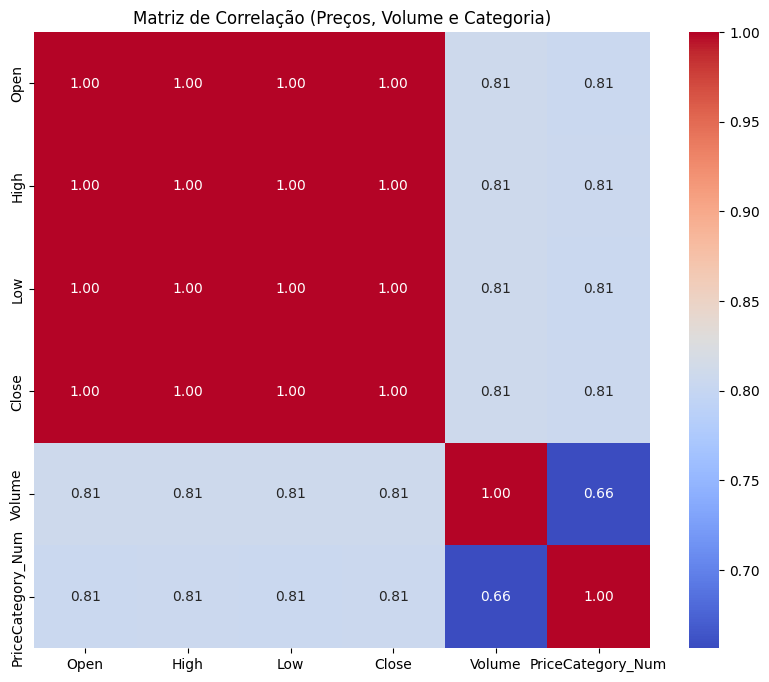

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

mapeamento = {'Low': 0, 'Medium': 1, 'High': 2}
df['PriceCategory_Num'] = df['PriceCategory'].map(mapeamento)


colunas_analise = ['Open', 'High', 'Low', 'Close', 'Volume', 'PriceCategory_Num']
matriz_corr = df[colunas_analise].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    square=True
)

plt.title('Matriz de Correlação (Preços, Volume e Categoria)')
plt.show()

## 2.2 Normalização dos Dados (StandardScaler)
Antes de aplicar o PCA, é essencial normalizar os dados para que todas as variáveis contribuam igualmente na análise.  
Utilizamos o **StandardScaler** do scikit-learn, que transforma cada feature para ter **média 0** e **desvio padrão 1** (normalização Z-score).

In [6]:
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('bitcoin_limpo_ordenado.csv')


colunas_numericas = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[colunas_numericas]


scaler = StandardScaler()
X_normalizado = scaler.fit_transform(X)


df_normalizado = pd.DataFrame(X_normalizado, columns=colunas_numericas)

print('Estatísticas ANTES da normalização:')
print(X.describe().round(2))
print('\nEstatísticas DEPOIS da normalização:')
print(df_normalizado.describe().round(2))

Estatísticas ANTES da normalização:
           Open      High       Low     Close        Volume
count   5883.00   5883.00   5883.00   5883.00  5.883000e+03
mean   21725.05  21973.72  21487.58  21736.78  1.087915e+08
std    30114.98  30445.26  29793.03  30119.95  1.851098e+08
min        0.30      0.30      0.29      0.30  3.030000e+01
25%      430.57    431.21    422.13    430.57  1.271205e+06
50%     7193.60   7207.98   7057.97   7193.60  1.756809e+07
75%    42265.19  42370.14  41483.58  42265.19  1.302297e+08
max    93429.20  95281.01  93326.45  93429.20  9.325168e+08

Estatísticas DEPOIS da normalização:
          Open     High      Low    Close   Volume
count  5883.00  5883.00  5883.00  5883.00  5883.00
mean      0.00    -0.00     0.00     0.00    -0.00
std       1.00     1.00     1.00     1.00     1.00
min      -0.72    -0.72    -0.72    -0.72    -0.59
25%      -0.71    -0.71    -0.71    -0.71    -0.58
50%      -0.48    -0.49    -0.48    -0.48    -0.49
75%       0.68     0.67     0

## 2.3 Análise de Componentes Principais (PCA)
O PCA reduz a dimensionalidade projetando os dados em um novo sistema de coordenadas que maximiza a variância.  
Aqui, extraímos os **dois componentes principais** e visualizamos os dados em 2D, coloridos pela `PriceCategory`.

Variância explicada pelo PC1: 0.9410 (94.10%)
Variância explicada pelo PC2: 0.0588 (5.88%)
Variância total explicada:     0.9998 (99.98%)


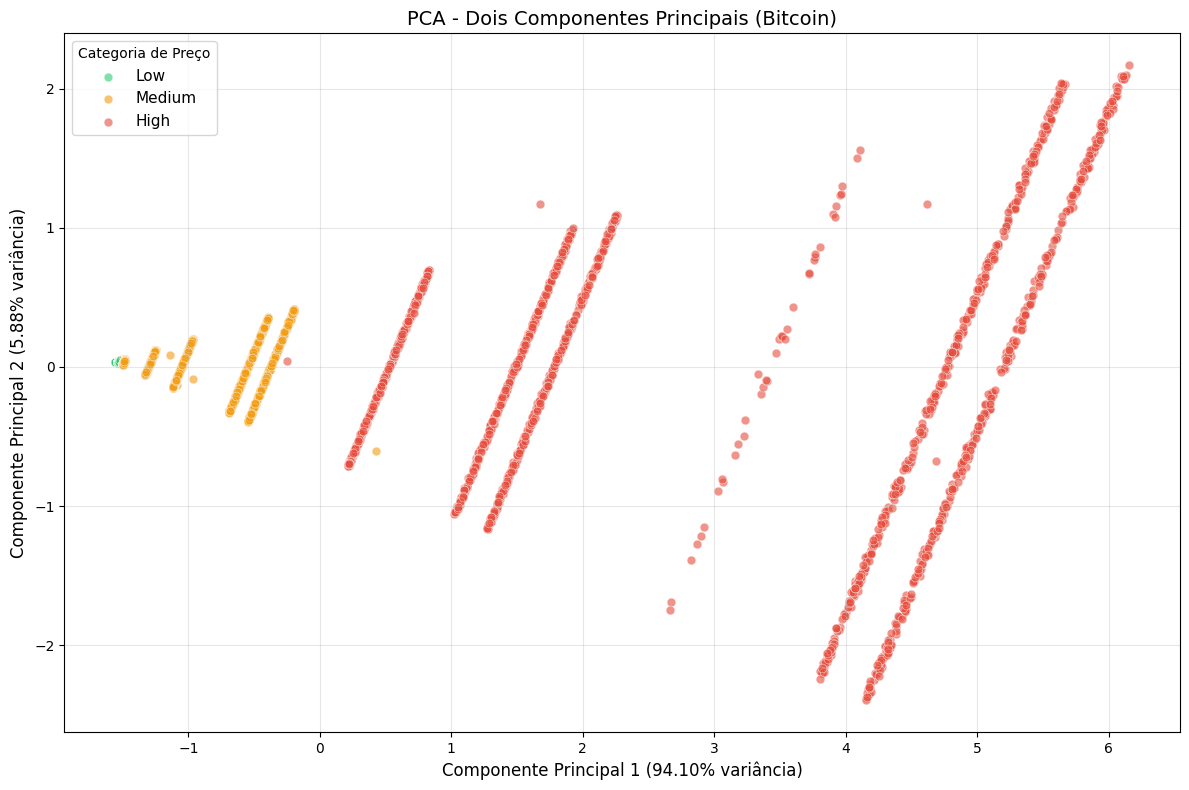

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_normalizado)

print(f'Variância explicada pelo PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)')
print(f'Variância explicada pelo PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)')
print(f'Variância total explicada:     {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)')

df_pca = pd.DataFrame({
    'PC1': componentes[:, 0],
    'PC2': componentes[:, 1],
    'PriceCategory': df['PriceCategory']
})

plt.figure(figsize=(12, 8))

cores = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

for categoria, cor in cores.items():
    mask = df_pca['PriceCategory'] == categoria
    plt.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        c=cor,
        label=categoria,
        alpha=0.6,
        edgecolors='w',
        linewidth=0.5,
        s=40
    )

plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variância)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variância)', fontsize=12)
plt.title('PCA - Dois Componentes Principais (Bitcoin)', fontsize=14)
plt.legend(title='Categoria de Preço', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()